## Part 1: Flight Tickets API Exploration
APIs, which stands for Application Programming Interfaces, are powerful tools that facilitate communication and interaction between different software applications. They act as intermediaries, allowing developers to access and use data or functionality from other systems without starting from scratch. Essentially, APIs provide a standardized way for applications to seamlessly exchange information.

Accessing API data is another one of the means to acquire information from web pages. In the project, we will use the Kayak API website and extract the flight data required.

**Step 1:** Issue a request to the Kayak explore API page.

In [134]:
import requests
from requests.exceptions import HTTPError

import pandas as pd
import seaborn as sns

In [76]:
# Specify the departure airport: LAX
airport = "LAX"
# TODO: specify the departure and returning dates (YYYY-MM-DD) in strings as follows
dep = "2024-07-10"
ret = "2024-07-20"

In [77]:
url = "https://www.kayak.com/s/horizon/exploreapi/destinations?airport=" + airport + "&bugget=&depart=" \
      + dep + "&return=" + ret + "&tripdurationrange=4%2C7&duration=&flightMaxStops=&stopsFilterActive=false&topRightLat=&topRightLon=&bottomLeftLat=&bottomLeftLon=&zoomLevel=5&selectedMarker=&themeCode=&selectedDestination="

In [78]:
# TODO: get the response from the url you specified
# Hint: use the try-except block to gracefully handle error status if there is any!
try:
    # Issue the request
    response = requests.get(url)
    response.raise_for_status()  # Raise HTTPError for bad responses
    
except HTTPError as http_err:
    print(f"HTTP error occurred: {http_err}")
except Exception as err:
    print(f"Other error occurred: {err}")

In [79]:
# Convert the response information to a dictionary type
tickets_dict = response.json()
# Inspect the keys of the resulting dictionary
tickets_dict.keys()

dict_keys(['destinations', 'origin'])

In [85]:
dests = tickets_dict['destinations']

Step 2: Initialize a dictionary to store the scraped data.

In [86]:
# TODO: start by establishing a dictionary, with the following keys -
# 'destination_city', 'relevancy_score', 'airline', 'price', 'duration', 'stop'
# each of these keys will map to a value of list type
result_dict = {
    'destination_city': [],
    'relevancy_score': [],
    'airline': [],
    'price': [],
    'duration': [],
    'stop': []
}

# Print the initialized dictionary to verify
print(result_dict)

{'destination_city': [], 'relevancy_score': [], 'airline': [], 'price': [], 'duration': [], 'stop': []}


**Step 3:** Get all destination city names and relavancy score from `dests`, and store them into `result_dict`.

In [87]:
# TODO: as described above, append all the resulting city names to result_dict['destination_city']
# Extract destination city names and relevancy scores from 'dests'
for destination in dests:
    city_name = destination.get('city')['name']
    relevancy_score = destination.get('relevancyScore')
    
    # Append the extracted information to the respective lists in result_dict
    result_dict['destination_city'].append(city_name)
    result_dict['relevancy_score'].append(relevancy_score)


**Step 4:** Get the airline name from `dests`, and store them into `result_dict`.

In [88]:
# TODO: ^
for destination in dests:
    airline = destination.get('airline')
    result_dict['airline'].append(airline)

**Step 5:** Get the ticket price, flight max duration, and flight max stops from `dests`, and store them into corresponding entries of `result_dict`.

In [89]:
# TODO: ^
for destination in dests:
    price = destination.get('flightInfo')['price']
    duration = destination.get('flightMaxDuration')
    stop = destination.get('flightMaxStops')
    
    # Append the extracted information to the respective lists in result_dict
    result_dict['price'].append(price)
    result_dict['duration'].append(duration)
    result_dict['stop'].append(stop)

**Step 6:** Plot the flight information with Seaborn relplot, use x axis for flight duration, y axis for ticket price, and use dot size to represent the number of stops over the flight.

In [91]:
# TODO: construct a dataframe from the dictionary you've just constracted
df = pd.DataFrame(result_dict)
df

,destination_city,relevancy_score,airline,price,duration,stop
0,Incheon,1000,China Eastern,753.0,1885,1
1,Paris,814,WestJet,487.0,1230,1
2,New York,807,Spirit Airlines,136.0,1653,1
3,London,787,Norse Atlantic UK,441.0,685,0
4,Copenhagen,765,Scandinavian Airlines,521.0,660,0
...,...,...,...,...,...,...
1153,Port Royal,170,United Airlines,4018.0,687,2
1154,Tarawa,151,Multiple Airlines,4231.0,2540,2
1155,Londonderry,126,British Airways,4515.0,1200,1
1156,Blantyre,72,Multiple Airlines,5105.0,1965,3


In [93]:
# TODO: sort the flights by their relavancy scores in-place by descending order
df.sort_values(by='relevancy_score', ascending=False, inplace=True)
df

,destination_city,relevancy_score,airline,price,duration,stop
0,Incheon,1000,China Eastern,753.0,1885,1
1,Paris,814,WestJet,487.0,1230,1
2,New York,807,Spirit Airlines,136.0,1653,1
3,London,787,Norse Atlantic UK,441.0,685,0
4,Copenhagen,765,Scandinavian Airlines,521.0,660,0
...,...,...,...,...,...,...
1153,Port Royal,170,United Airlines,4018.0,687,2
1154,Tarawa,151,Multiple Airlines,4231.0,2540,2
1155,Londonderry,126,British Airways,4515.0,1200,1
1156,Blantyre,72,Multiple Airlines,5105.0,1965,3


/Users/mac/anaconda3/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


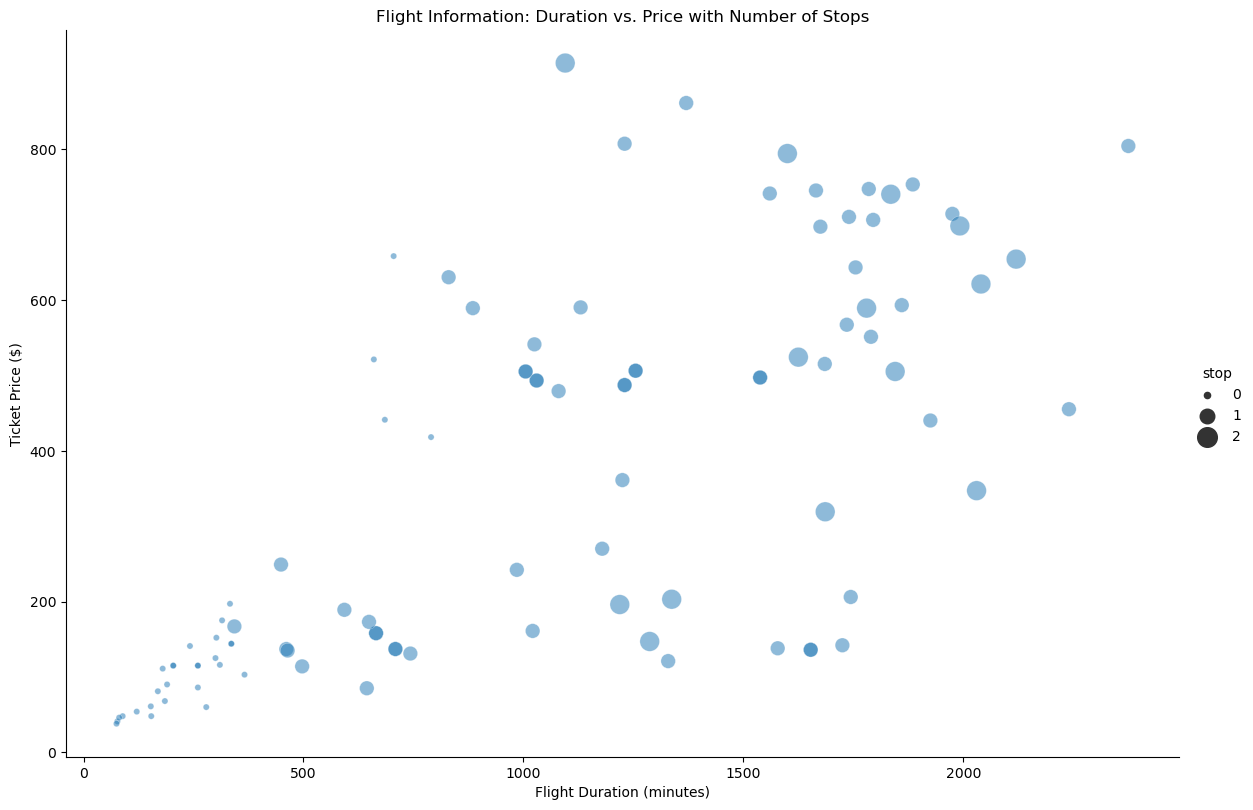

In [94]:
# TODO: for flights with the top 100 relavancy scores, plot the flight information as specified
import matplotlib.pyplot as plt
top_100_df = df.head(100)

# Plot using Seaborn's relplot
sns.relplot(
    data=top_100_df,
    x='duration',
    y='price',
    size='stop',
    sizes=(20, 200),  # Adjust the size range of the dots
    alpha=0.5,  # Transparency of the dots
    height=8,  # Height of the plot
    aspect=1.5  # Aspect ratio of the plot
)

# Add labels and title to the plot
plt.xlabel('Flight Duration (minutes)')
plt.ylabel('Ticket Price ($)')
plt.title('Flight Information: Duration vs. Price with Number of Stops')

# Show the plot
plt.show()

## Part 2: Barnes & Noble Best Selling Books

In this part, we'll inspect Barnes & Noble's website to fetch the information about the top 20 best selling books of the store. The overall process will be a lot similar to what has been demonstrated in the class.

In [135]:
from bs4 import BeautifulSoup

In [136]:
url = "https://www.barnesandnoble.com/b/books/_/N-1fZ29Z8q8"

**Step 1:** Get response from url

In [137]:
# TODO: get response from url with the requests library
try:
    kv = {"user-agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/605.1.15 (KHTML, like Gecko) Version/16.3 Safari/605.1.15"}
    response = requests.get(url, headers = kv)

    # If the response was successful, no excpetions will be raised
    response.raise_for_status()
except HTTPError as http_err:
    print("HTTP error occurred: {}".format(http_err))
except Exception as err:
    print("Other error occurred: {}".format(err))
else:
    print("Success!")

Success!


**Step 2:** Create a BeautifulSoup object, and inspect the html source of the target website.

In [139]:
# TODO: create a beautiful soup object from the response you get
soup = BeautifulSoup(response.content, 'html.parser')
print(soup.prettify())  # Print formatted HTML

<!DOCTYPE html>
<html class="no-js" lang="en">
 <head>
  <meta content="text/html; charset=utf-8" http-equiv="Content-Type"/>
  <meta content="IE=edge,chrome=1" http-equiv="X-UA-Compatible"/>
  <meta content="True" name="HandheldFriendly"/>
  <meta content="320" name="MobileOptimized"/>
  <meta content="width=device-width, initial-scale=1.0" name="viewport"/>
  <meta content="telephone=no" name="format-detection"/>
  <meta content="Barnes &amp; Noble" name="author"/>
  <title>
   Bestselling Books | Best Books to Read Right Now | Barnes &amp; Noble®
  </title>
  <!-- set meta description -->
  <meta content="Explore Barnes &amp; Noble's top 100 bestselling books. Browse good books to read by your favorite authors, buzzworthy non-fiction, best cookbooks, and more." name="description">
   <meta content="summary" name="twitter:card">
    <meta content="@BNBuzz" name="twitter:site">
     <meta content="Bestselling Books | Best Books to Read Right Now" property="og:title">
      <meta conte

**Step 3:** Based on the pattern that you have found, extract all contents (tag segments) under the tag or class you've figured out based on the html source. Remember that you could always inspect the parent of the current tag by visiting `.parent`!

In [148]:
# TODO: ^
book_containers = soup.find_all('div', class_='product-info-view')
book_containers

[<div class="product-info-view">
 <div class="product-shelf-title"><h3 class="product-info-title">
 <a class="" href="/w/hunger-games-4-book-paperback-boxed-set-deluxe-edition-suzanne-collins/1145900528;jsessionid=A178ADB39F28FA814ACD0D3CC73F580E.prodny_store02-atgap03?ean=9781546171904" onclick="set_cookie('txl__Hunger-Games-4-Book-Paperback-Boxed-Set-Deluxe-Edition/Suzanne-Collins_text');" title="">Hunger Games 4-Book Paperback Boxed Set Deluxe Edition (The Hunger Games, Catching Fire, Mockingjay, The Ballad of Songbirds and Snakes)</a><span class="text--small publ-date"> (02/04/2025)</span>
 </h3></div>
 <!-- ATG-18359 start-->
 <!-- AT-589 code fix for Data Oddity Start-->
 <!-- AT-589 code fix for Data Oddity :End-->
 <!-- AT-589 code fix for Data Oddity-->
 <div class="product-shelf-author contributors truncate">by <a href="/b/contributor/suzanne-collins/_/N-2kn6;jsessionid=A178ADB39F28FA814ACD0D3CC73F580E.prodny_store02-atgap03">Suzanne Collins</a></div>
 <div data-bv-product-id

**Step 4:** Fetch the book information (name and price) from the scraped content.

In [160]:
# TODO: use a for loop, get the book information from the html content you've scraped
# store the information into an organized data structure
# Initialize an empty list to store book details
books = []

# Loop through each container and extract the required information
for container in book_containers[:20]:  # Limit to top 20 books
    # Extract the book title
    #title_container = container.find('h3', class_='product-info-title')
    #title = title_container.get_text(strip=True) if title_container else 'No Title'
    title_container = container.find('h3', class_='product-info-title')
    title = title_container.get_text(strip=True).split('(')[0] 
    # Extract the book price
    price_container = container.find('span', class_='current')
    price = price_container.get_text(strip=True) if price_container else 'No Price'
    
    
    # Create a dictionary of the book details
    book_details = {
        'title': title,
        'price': price
    }
    
    # Append the book details to the list
    books.append(book_details)

# Print the list of books
for i, book in enumerate(books, start=1):
    print(f"{i}. Title: {book['title']}, Price: {book['price']}")

1. Title: Hunger Games 4-Book Paperback Boxed Set Deluxe Edition , Price: $54.36
2. Title: Reckless , Price: $21.99
3. Title: A Death in Cornwall: A Novel, Price: $19.99
4. Title: Onyx Storm , Price: $32.99
5. Title: The Book of Bill , Price: $26.99
6. Title: Flashpoint: An FBI Thriller, Price: $21.00
7. Title: Half Baked Harvest: Quick & Cozy, Price: $29.69
8. Title: Hard to Kill: Meet James Patterson's Greatest Character Yet, Price: $21.00
9. Title: One Dark Window, Price: $18.99
10. Title: Two Twisted Crowns, Price: $17.09
11. Title: Sunrise on the Reaping , Price: $22.39
12. Title: Clive Cussler Ghost Soldier, Price: $22.40
13. Title: Angel of Vengeance, Price: $21.00
14. Title: Apprentice to the Villain , Price: $19.99
15. Title: Shadow of Doubt: A Thriller , Price: $29.99
16. Title: Zodiac Academy: The Awakening, Price: $20.99
17. Title: The Women: A Novel, Price: $21.00
18. Title: Capture or Kill: A Mitch Rapp Novel by Don Bentley, Price: $20.99
19. Title: The Fox and the Falcon